**Transient & MCMC I**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [3]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [4]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the log-prior
def logPrior(theta):
    b, A, alpha, t0 = theta
    if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
        return -np.log(alpha) 
    return -np.inf 

# Define the log-posterior
def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

In [5]:
ndim = 4
nwalkers = 50

We need to take into account a thermalization time, plus the autocorralation. We run a smal test to set the burn and the thinning for the chain.

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_50455/2480525843.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 2000/2000 [00:02<00:00, 889.01it/s]


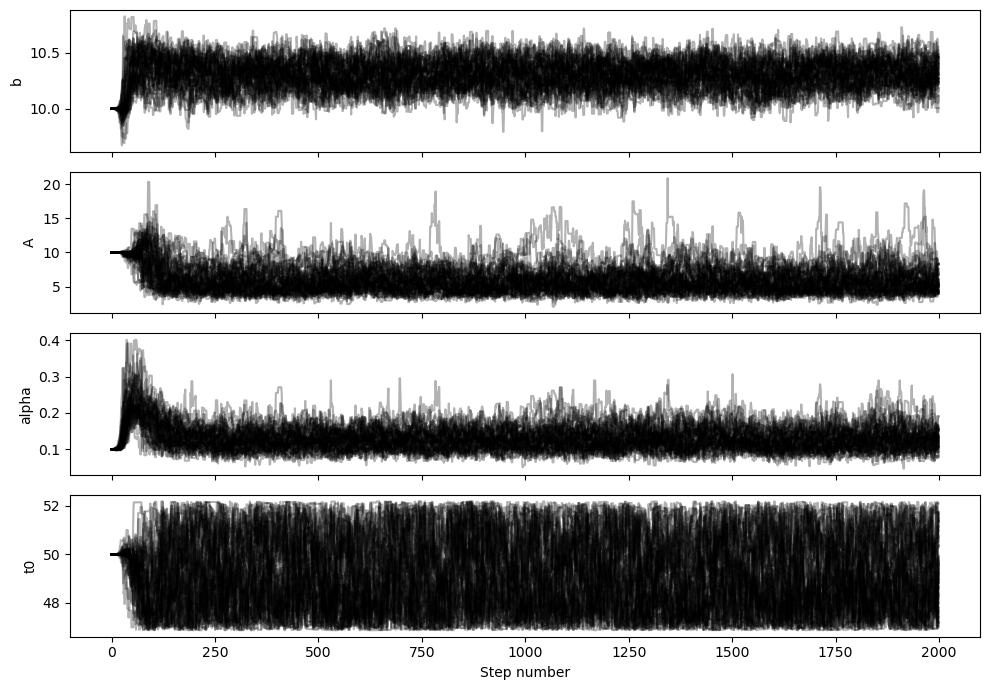

In [29]:
burn = 2000
try_sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sempler.run_mcmc(initial_pos, burn, progress=True)

traces = try_sempler.get_chain()
labels = ["b", "A", "alpha", "t0"]
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(traces[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

Let's conclude that we need at least 100 steps to burn the chain.

In [30]:
tau = try_sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [40.5029838  68.5832734  51.58908824 58.2764432 ]

In [6]:
# Run the sampler for a longer time to get better estimates, considering the autocorrelation time
burn = 100
nsteps = 10000

sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))

initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)

sempler.run_mcmc(initial_pos, nsteps, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_80014/2480525843.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 10000/10000 [00:11<00:00, 882.84it/s]


State([[10.28259658  5.85478668  0.11879688 47.56172675]
 [10.21169866  3.87697284  0.0989135  50.24184066]
 [10.30674157  4.87977993  0.11158189 48.16166754]
 [10.29190914  7.38292344  0.1242391  46.95017231]
 [10.11318575  6.14496592  0.10341138 47.93792525]
 [10.3153468   4.51676574  0.10424051 48.18297257]
 [10.36198456  5.23008712  0.1383092  50.44432659]
 [10.34834037  6.83951338  0.12623654 47.01703169]
 [10.24448104  8.93196493  0.16212409 47.28819744]
 [10.37808323  4.18118175  0.10470481 49.61107406]
 [10.26586481  8.58045148  0.13790743 47.41808166]
 [10.35184803  6.27136259  0.12295769 48.3881964 ]
 [10.17512386  4.9379375   0.08577916 47.35296726]
 [10.35789029  4.76106012  0.0907159  46.91274196]
 [10.34911427  4.25832456  0.18632687 51.8359412 ]
 [10.58071251  5.3993421   0.19174834 50.51791428]
 [10.5127992   7.06518191  0.14968067 47.61054585]
 [10.54671128  4.82369579  0.10977342 48.38591914]
 [10.20688732  6.60468306  0.16968774 50.29274173]
 [10.32281662  4.84755238

In [7]:
tau = sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

[52.36664943 75.63212879 60.72841731 73.46782745]


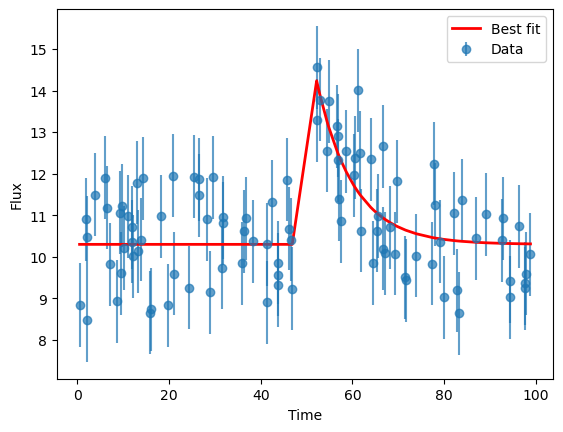

In [8]:
samples = sempler.get_chain(discard=burn, thin=thin, flat=True)

best_params = samples.mean(axis=0)

plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best fit', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

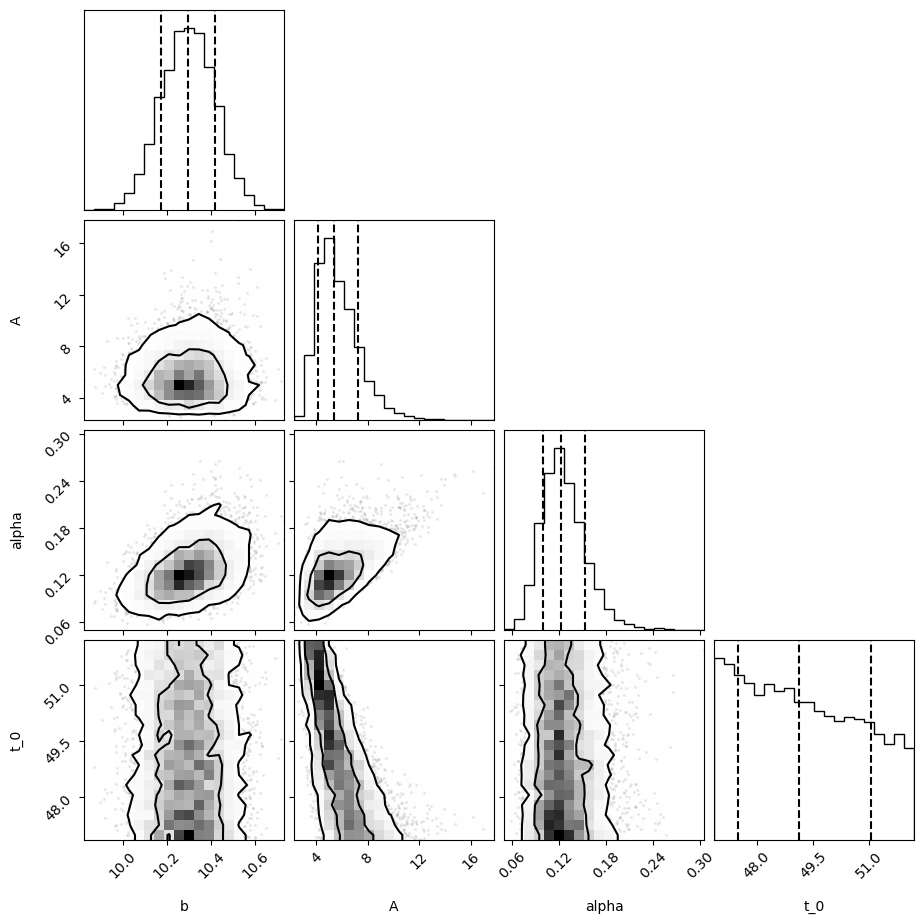

In [20]:
import corner as corner

labels = ["b", "A", "alpha", "t_0"]

fig = corner.corner(
    samples, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

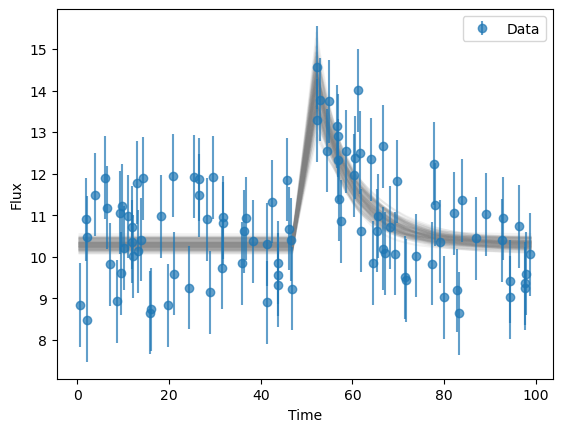

In [14]:
random_samples = samples[np.random.choice(samples.shape[0], size=100, replace=False)]

for i in range(len(random_samples)):
    y = Model(time, *random_samples[i])
    plt.plot(time, y, color='gray', alpha=0.1)
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()


In [18]:
median_params = np.median(samples, axis=0)
percentiles_params = np.percentile(samples, [5, 95], axis=0)

for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

b: 10.295 (+0.199, -0.199)
A: 5.392 (+3.332, -1.770)
alpha: 0.123 (+0.054, -0.037)
t0: 49.113 (+2.690, -2.048)


*hint* : we can check also the walker bheaviuor...